# AEM 5840 Final Project: Chicago Crime Patterns and Public Safety

**Team members:** Chenghao Liu, Xinyue Pan, Ryan Shelley, Yonglin Zhang

**Main research question:** How do crime incidents in Chicago vary by time, place, and crime type in 2024, and which district-time-crime combinations appear to need the most public safety attention?

This notebook completes and polishes five project responsibilities:

1. **A: Data Foundation + Integration** - full API pull, cleaning, missing values, data dictionary, and export files.
2. **B: Temporal Analysis** - crime by hour, weekday, month, hour-by-weekday heatmap, top crime types over time, and arrest rate over time.
3. **C: Spatial Analysis + Map** - district and community-area patterns, Folium heatmap, police station markers, and approximate nearest-station distance.
4. **D: Crime Type + Arrest + COPA Supplement** - offense type patterns, arrest outcomes, domestic comparison, location categories, Plotly interactive chart, and high-level COPA context.
5. **E: Final Synthesis + Limitations** - integrated decision-support priority ranking, final takeaways, and responsible interpretation limits.


## A. Data Foundation + Integration

This section builds the clean 2024 crime dataset used by the rest of the project. The original file only used the first 50,000 API records, which stopped in March 2024. The updated version uses pagination and a full-year date filter so the final data covers **January 1, 2024 through December 31, 2024**.

**Primary source:** City of Chicago Data Portal, Crimes - 2001 to Present, dataset ID `ijzp-q8t2`.

**Exports created by this section:**

- `chicago_crimes_2024_clean.csv`
- `crimes_map_ready.csv`
- `data_dictionary.csv`


In [2]:
import calendar

import matplotlib.pyplot as plt
import pandas as pd
import requests
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

CRIME_API_URL = "https://data.cityofchicago.org/resource/ijzp-q8t2.json"
CLEAN_FILE = "chicago_crimes_2024_clean.csv"
MAP_READY_FILE = "crimes_map_ready.csv"
DATA_DICTIONARY_FILE = "data_dictionary.csv"

SELECT_COLUMNS = [
    "id",
    "case_number",
    "date",
    "primary_type",
    "description",
    "location_description",
    "arrest",
    "domestic",
    "beat",
    "district",
    "ward",
    "community_area",
    "latitude",
    "longitude",
]

WHERE_CLAUSE = "date >= '2024-01-01T00:00:00' AND date < '2025-01-01T00:00:00'"
PAGE_SIZE = 50000

WEEKDAY_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
MONTH_ORDER = list(calendar.month_name)[1:]


In [3]:
def fetch_chicago_crime_2024():
    """Download full-year 2024 Chicago crime incidents using Socrata pagination."""
    offset = 0
    records = []

    while True:
        params = {
            "$select": ",".join(SELECT_COLUMNS),
            "$where": WHERE_CLAUSE,
            "$order": "date ASC, id ASC",
            "$limit": PAGE_SIZE,
            "$offset": offset,
        }

        response = requests.get(CRIME_API_URL, params=params, timeout=60)
        response.raise_for_status()
        page = response.json()

        if not page:
            break

        records.extend(page)
        print(f"Downloaded {len(records):,} records...")

        if len(page) < PAGE_SIZE:
            break

        offset += PAGE_SIZE

    return pd.DataFrame(records)


def clean_crime_data(raw_df):
    """Clean crime incident fields and create time variables used by the analysis sections."""
    df = raw_df.copy()

    for column in SELECT_COLUMNS:
        if column not in df.columns:
            df[column] = pd.NA

    df = df[SELECT_COLUMNS]
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    numeric_columns = ["id", "latitude", "longitude", "beat", "district", "ward", "community_area"]
    for column in numeric_columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

    for column in ["arrest", "domestic"]:
        df[column] = df[column].map({"true": True, "false": False, True: True, False: False})

    df = df.dropna(subset=["date"])

    for column in ["case_number", "primary_type", "description", "location_description"]:
        df[column] = df[column].astype("string").str.strip()

    for column in ["primary_type", "description", "location_description"]:
        df[column] = df[column].str.upper()

    df["hour"] = df["date"].dt.hour
    df["day_of_week"] = df["date"].dt.day_name()
    df["month"] = df["date"].dt.month
    df["month_name"] = df["date"].dt.month_name()
    df["year"] = df["date"].dt.year
    df["is_weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"])

    return df


raw_df = fetch_chicago_crime_2024()
df = clean_crime_data(raw_df)

df.to_csv(CLEAN_FILE, index=False)
df_map = df.dropna(subset=["latitude", "longitude"]).copy()
df_map.to_csv(MAP_READY_FILE, index=False)

print("Cleaned dataset shape:", df.shape)
print("Map-ready dataset shape:", df_map.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())
print("Saved files:", CLEAN_FILE, "and", MAP_READY_FILE)


Downloaded 50,000 records...
Downloaded 100,000 records...
Downloaded 150,000 records...
Downloaded 200,000 records...
Downloaded 250,000 records...
Downloaded 259,111 records...
Cleaned dataset shape: (259111, 20)
Map-ready dataset shape: (257531, 20)
Date range: 2024-01-01 00:00:00 to 2024-12-31 23:58:00
Saved files: chicago_crimes_2024_clean.csv and crimes_map_ready.csv


In [4]:
data_dictionary = pd.DataFrame([
    ["id", "Chicago Crimes API", "numeric", "Unique record identifier from the City of Chicago crime dataset", "Converted to numeric where possible and retained for ordering and QA"],
    ["case_number", "Chicago Crimes API", "string", "Police case number associated with the incident", "Trimmed and retained as an identifier"],
    ["date", "Chicago Crimes API", "datetime", "Date and time when the incident occurred", "Converted to datetime; rows with missing or invalid dates are removed"],
    ["primary_type", "Chicago Crimes API", "string", "High-level offense category such as THEFT or BATTERY", "Trimmed and converted to uppercase"],
    ["description", "Chicago Crimes API", "string", "More detailed offense description", "Trimmed and converted to uppercase"],
    ["location_description", "Chicago Crimes API", "string", "Type of place where the incident occurred", "Trimmed and converted to uppercase; missing values retained"],
    ["arrest", "Chicago Crimes API", "boolean", "Whether an arrest was recorded for the incident", "Converted from API true/false values to Boolean"],
    ["domestic", "Chicago Crimes API", "boolean", "Whether the incident was marked as domestic-related", "Converted from API true/false values to Boolean"],
    ["beat", "Chicago Crimes API", "numeric", "Police beat associated with the incident", "Converted to numeric where possible"],
    ["district", "Chicago Crimes API", "numeric", "Police district associated with the incident", "Converted to numeric where possible"],
    ["ward", "Chicago Crimes API", "numeric", "Chicago ward associated with the incident", "Converted to numeric where possible"],
    ["community_area", "Chicago Crimes API", "numeric", "Chicago community area code associated with the incident", "Converted to numeric where possible; small number of missing values retained"],
    ["latitude", "Chicago Crimes API", "numeric", "Latitude coordinate for the incident", "Converted to numeric; missing values retained in clean file and removed from map-ready file"],
    ["longitude", "Chicago Crimes API", "numeric", "Longitude coordinate for the incident", "Converted to numeric; missing values retained in clean file and removed from map-ready file"],
    ["hour", "Derived", "numeric", "Hour of day extracted from date using 24-hour time", "Created from the cleaned date column"],
    ["day_of_week", "Derived", "string", "Name of the weekday extracted from date", "Created from the cleaned date column"],
    ["month", "Derived", "numeric", "Month number extracted from date", "Created from the cleaned date column"],
    ["month_name", "Derived", "string", "Month name extracted from date", "Created from the cleaned date column"],
    ["year", "Derived", "numeric", "Year extracted from date", "Created from the cleaned date column; should equal 2024 for this project"],
    ["is_weekend", "Derived", "boolean", "Indicator for Saturday or Sunday incidents", "Created from day_of_week"],
], columns=["column", "source", "type", "description", "cleaning_notes"])

data_dictionary.to_csv(DATA_DICTIONARY_FILE, index=False)
display(data_dictionary)
print("Saved file:", DATA_DICTIONARY_FILE)


,column,source,type,description,cleaning_notes
0,id,Chicago Crimes API,numeric,Unique record identifier from the City of Chic...,Converted to numeric where possible and retain...
1,case_number,Chicago Crimes API,string,Police case number associated with the incident,Trimmed and retained as an identifier
2,date,Chicago Crimes API,datetime,Date and time when the incident occurred,Converted to datetime; rows with missing or in...
3,primary_type,Chicago Crimes API,string,High-level offense category such as THEFT or B...,Trimmed and converted to uppercase
4,description,Chicago Crimes API,string,More detailed offense description,Trimmed and converted to uppercase
5,location_description,Chicago Crimes API,string,Type of place where the incident occurred,Trimmed and converted to uppercase; missing va...
6,arrest,Chicago Crimes API,boolean,Whether an arrest was recorded for the incident,Converted from API true/false values to Boolean
7,domestic,Chicago Crimes API,boolean,Whether the incident was marked as domestic-re...,Converted from API true/false values to Boolean
8,beat,Chicago Crimes API,numeric,Police beat associated with the incident,Converted to numeric where possible
9,district,Chicago Crimes API,numeric,Police district associated with the incident,Converted to numeric where possible


Saved file: data_dictionary.csv


In [5]:
missing_overview = (
    df.isna().sum()
    .rename("missing_count")
    .reset_index()
    .rename(columns={"index": "column"})
)
missing_overview["missing_percent"] = (missing_overview["missing_count"] / len(df) * 100).round(2)
missing_overview = missing_overview.sort_values("missing_count", ascending=False)

quality_summary = pd.DataFrame({
    "metric": [
        "cleaned_rows",
        "cleaned_columns",
        "map_ready_rows",
        "records_removed_from_map_file",
        "date_min",
        "date_max",
        "unique_primary_types",
        "unique_districts",
        "overall_arrest_rate",
    ],
    "value": [
        len(df),
        df.shape[1],
        len(df_map),
        len(df) - len(df_map),
        df["date"].min(),
        df["date"].max(),
        df["primary_type"].nunique(),
        df["district"].nunique(),
        round(df["arrest"].mean() * 100, 2),
    ],
})

display(quality_summary)
display(missing_overview)


,metric,value
0,cleaned_rows,259111
1,cleaned_columns,20
2,map_ready_rows,257531
3,records_removed_from_map_file,1580
4,date_min,2024-01-01 00:00:00
5,date_max,2024-12-31 23:58:00
6,unique_primary_types,31
7,unique_districts,23
8,overall_arrest_rate,13.83


,column,missing_count,missing_percent
13,longitude,1580,0.61
12,latitude,1580,0.61
5,location_description,1136,0.44
11,community_area,7,0.00
0,id,0,0.00
18,year,0,0.00
17,month_name,0,0.00
16,month,0,0.00
15,day_of_week,0,0.00
14,hour,0,0.00


### A. Data Foundation Summary

The cleaned dataset now uses the full 2024 Chicago crime incident records rather than the first API page. The working dataset has **259,111 incidents** and **20 columns**. The map-ready file has **257,531 incidents**, because **1,580 records** without latitude/longitude were removed for mapping only.

Missing values are limited and manageable for the current project goals. The most important missing fields are latitude/longitude, which are kept in the main clean file but removed from `crimes_map_ready.csv`; `location_description`, which is missing for 1,136 records; and `community_area`, which is missing for 7 records. These missing values should be mentioned as a limitation in the final report, but they do not block the temporal analysis.


## B. Temporal Analysis

This section studies when crime incidents are more common in the full 2024 dataset. It covers crime by hour, day of week, month, an hour-by-weekday heatmap, the monthly distribution of the top five crime types, and arrest rate over time.

For month and weekday comparisons, raw counts can be misleading because months have different numbers of days and 2024 has 53 Mondays and Tuesdays but 52 of the other weekdays. Therefore, this section includes normalized measures where useful.


In [17]:
import pandas as pd
import calendar

df = pd.read_csv(CLEAN_FILE, parse_dates=["date"])

df.head()
df.shape
df.columns


df["arrest"] = df["arrest"].astype(str)
df["arrest"] = df["arrest"].str.lower()
df["arrest"] = df["arrest"].eq("true")

df["domestic"] = df["domestic"].astype(str)
df["domestic"] = df["domestic"].str.lower()
df["domestic"] = df["domestic"].eq("true")


hour_counts = df["hour"].value_counts()
hour_counts = hour_counts.sort_index()

hour_counts_df = pd.DataFrame({
    "hour": hour_counts.index,
    "crime_count": hour_counts.values
})


weekday_counts = df["day_of_week"].value_counts()
weekday_counts = weekday_counts.reindex(WEEKDAY_ORDER)

weekday_counts_df = pd.DataFrame({
    "day_of_week": weekday_counts.index,
    "crime_count": weekday_counts.values
})



month_counts = df["month_name"].value_counts()
month_counts = month_counts.reindex(MONTH_ORDER)

month_counts_df = pd.DataFrame({
    "month": month_counts.index,
    "crime_count": month_counts.values
})


month_numbers = pd.Series(
    range(1, 13),
    index=MONTH_ORDER
)

days_in_month_list = []

for month_name in MONTH_ORDER:
    month_number = month_numbers[month_name]
    days = calendar.monthrange(2024, month_number)[1]
    days_in_month_list.append(days)

days_in_month = pd.Series(
    days_in_month_list,
    index=MONTH_ORDER
)

month_counts_per_day = month_counts / days_in_month
month_counts_per_day = month_counts_per_day.round(1)

month_per_day_df = pd.DataFrame({
    "month": month_counts.index,
    "raw_count": month_counts.values,
    "days_in_month": days_in_month.values,
    "incidents_per_day": month_counts_per_day.values
})


all_dates_2024 = pd.date_range("2024-01-01", "2024-12-31", freq="D")

weekday_occurrences = all_dates_2024.day_name().value_counts()
weekday_occurrences = weekday_occurrences.reindex(WEEKDAY_ORDER)

weekday_counts_per_day = weekday_counts / weekday_occurrences
weekday_counts_per_day = weekday_counts_per_day.round(1)

weekday_per_day_df = pd.DataFrame({
    "day_of_week": weekday_counts.index,
    "raw_count": weekday_counts.values,
    "calendar_occurrences": weekday_occurrences.values,
    "incidents_per_weekday_occurrence": weekday_counts_per_day.values
})


heatmap_data = df.groupby(["day_of_week", "hour"]).size()
heatmap_data = heatmap_data.unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(WEEKDAY_ORDER)


crime_type_counts = df["primary_type"].value_counts()

top5_crimes = crime_type_counts.head(5).index.tolist()



df_top5 = df[df["primary_type"].isin(top5_crimes)]

top5_monthly = df_top5.groupby(["month_name", "primary_type"]).size()
top5_monthly = top5_monthly.unstack(fill_value=0)
top5_monthly = top5_monthly.reindex(MONTH_ORDER)



monthly_arrest_rate = df.groupby("month_name")["arrest"].mean()
monthly_arrest_rate = monthly_arrest_rate.reindex(MONTH_ORDER)
monthly_arrest_rate = monthly_arrest_rate * 100
monthly_arrest_rate = monthly_arrest_rate.round(1)

monthly_arrest_rate_df = pd.DataFrame({
    "month": monthly_arrest_rate.index,
    "arrest_rate_percent": monthly_arrest_rate.values
})



hourly_arrest_rate = df.groupby("hour")["arrest"].mean()
hourly_arrest_rate = hourly_arrest_rate.sort_index()
hourly_arrest_rate = hourly_arrest_rate * 100
hourly_arrest_rate = hourly_arrest_rate.round(1)

hourly_arrest_rate_df = pd.DataFrame({
    "hour": hourly_arrest_rate.index,
    "arrest_rate_percent": hourly_arrest_rate.values
})


print("\n" + "="*70)
print("DATASET OVERVIEW")
print("="*70)

print("Dataset shape:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())

overall_arrest_rate = df["arrest"].mean() * 100
overall_arrest_rate = round(overall_arrest_rate, 1)

print("Overall arrest rate:", overall_arrest_rate, "%")


hour_summary = pd.DataFrame({
    "crime_count": hour_counts,
    "arrest_rate_percent": hourly_arrest_rate
})

print("****************************************************************")
print("TABLE 1: Hourly Crime Count and Arrest Rate")
print("****************************************************************")

display(hour_summary)


# Weekday summary
weekday_summary = pd.DataFrame({
    "raw_count": weekday_counts,
    "calendar_occurrences": weekday_occurrences,
    "incidents_per_weekday_occurrence": weekday_counts_per_day
})

print("****************************************************************")
print("TABLE 2: Weekday Crime Count and Incidents per Weekday Occurrence")
print("****************************************************************")

display(weekday_summary)


# Month summary
month_summary = pd.DataFrame({
    "raw_count": month_counts,
    "days_in_month": days_in_month,
    "incidents_per_day": month_counts_per_day,
    "arrest_rate_percent": monthly_arrest_rate
})

print("****************************************************************")
print("TABLE 3: Monthly Crime Count, Incidents per Day, and Arrest Rate")
print("****************************************************************")

display(month_summary)


# Top 5 crimes
print("****************************************************************")
print("TABLE 4: Top 5 Crime Types")
print("****************************************************************")

display(pd.DataFrame({
    "primary_type": top5_crimes,
    "crime_count": crime_type_counts.head(5).values
}))


# Top 5 crimes by month
print("****************************************************************")
print("TABLE 5: Top 5 Crime Types by Month")
print("****************************************************************")
display(top5_monthly)


# Heatmap data
print("****************************************************************")
print("TABLE 6: Heatmap Data - Day of Week by Hour")
print("****************************************************************")

display(heatmap_data)


DATASET OVERVIEW
Dataset shape: (259111, 20)
Date range: 2024-01-01 00:00:00 to 2024-12-31 23:58:00
Overall arrest rate: 13.8 %
****************************************************************
TABLE 1: Hourly Crime Count and Arrest Rate
****************************************************************


,crime_count,arrest_rate_percent
hour,,
0,17903,10.3
1,8645,14.3
2,7856,13.1
3,6695,10.3
4,5554,9.5
5,4759,9.0
6,4931,10.9
7,6485,11.9
8,8965,12.1


****************************************************************
TABLE 2: Weekday Crime Count and Incidents per Weekday Occurrence
****************************************************************


,raw_count,calendar_occurrences,incidents_per_weekday_occurrence
Monday,38084,53,718.6
Tuesday,36720,53,692.8
Wednesday,36645,52,704.7
Thursday,36113,52,694.5
Friday,37347,52,718.2
Saturday,37373,52,718.7
Sunday,36829,52,708.2


****************************************************************
TABLE 3: Monthly Crime Count, Incidents per Day, and Arrest Rate
****************************************************************


...

,primary_type,crime_count
0,THEFT,60542
1,BATTERY,46147
2,CRIMINAL DAMAGE,28554
3,ASSAULT,23482
4,MOTOR VEHICLE THEFT,21711


****************************************************************
TABLE 5: Top 5 Crime Types by Month
****************************************************************


primary_type,ASSAULT,BATTERY,CRIMINAL DAMAGE,MOTOR VEHICLE THEFT,THEFT
month_name,,,,,
January,1729,3292,2107,1769,4379
February,1736,3472,2189,1880,4352
March,1890,3689,2467,1883,4500
April,1970,3791,2253,1656,4550
May,2293,4453,2405,1810,5201
June,2080,4295,2577,2046,5490
July,2126,4142,2600,1978,6067
August,2042,3905,2591,2013,5723
September,2125,4168,2511,1871,5388


****************************************************************
TABLE 6: Heatmap Data - Day of Week by Hour
****************************************************************


hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
day_of_week,,,,,,,,,,,,,,,,,,,,,,,,
Monday,2853,1261,1082,882,784,724,738,1047,1437,1606,1680,1624,2293,1697,1751,2118,1971,2077,2053,1995,1895,1747,1473,1296
Tuesday,2282,991,872,792,713,579,672,981,1420,1602,1644,1771,2273,1803,1870,2048,2008,2115,2027,1959,1792,1667,1532,1307
Wednesday,2322,1004,894,800,676,640,755,954,1424,1611,1636,1644,2226,1836,1783,2108,2104,2022,1927,1941,1810,1719,1511,1298
Thursday,2304,955,884,763,662,644,729,1018,1282,1594,1636,1692,2208,1589,1788,2026,2006,1985,1966,1878,1849,1656,1605,1394
Friday,2507,1088,948,837,740,638,641,952,1321,1601,1617,1661,2149,1721,1796,2102,2050,2094,2050,1860,1824,1728,1756,1666
Saturday,2681,1517,1457,1199,909,687,750,765,1055,1327,1454,1551,1968,1535,1685,1827,1932,1944,1856,1947,1919,1720,1896,1792
Sunday,2954,1829,1719,1422,1070,847,646,768,1026,1307,1366,1386,1861,1512,1585,1703,1791,1774,1859,1811,1771,1722,1641,1459


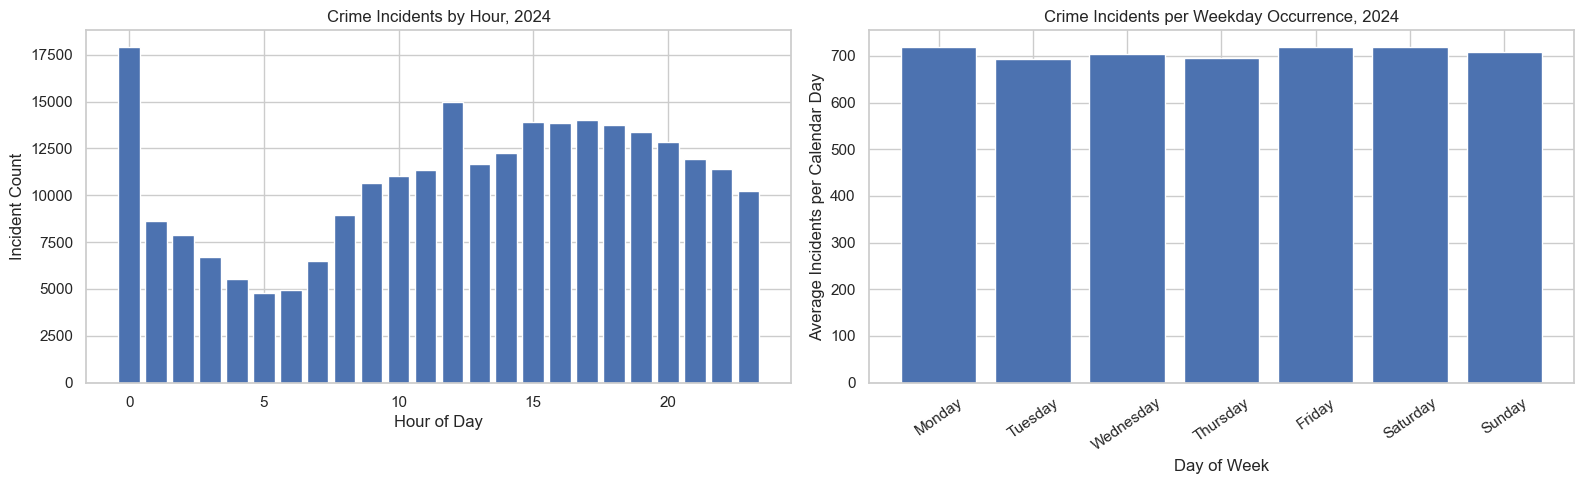

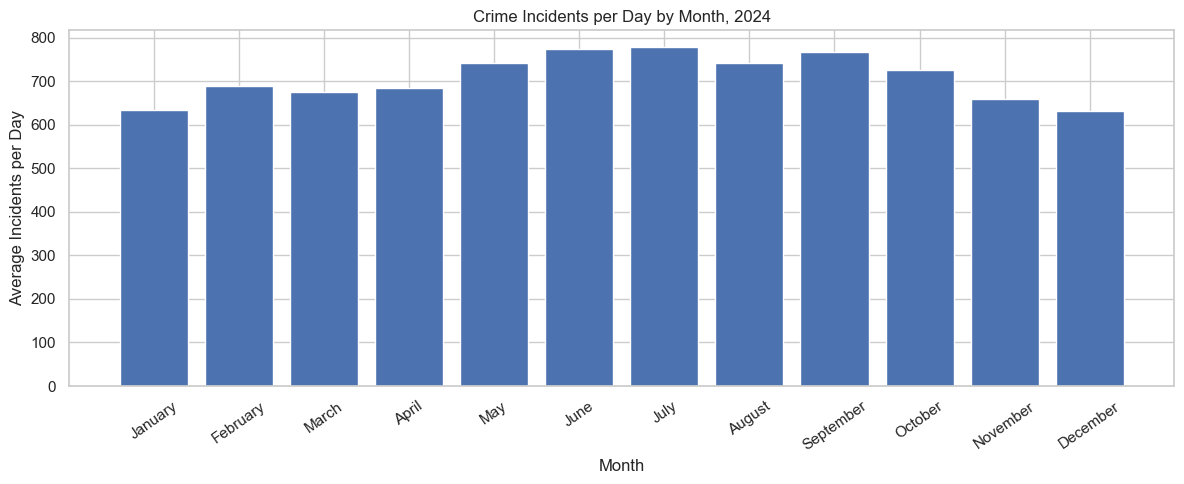

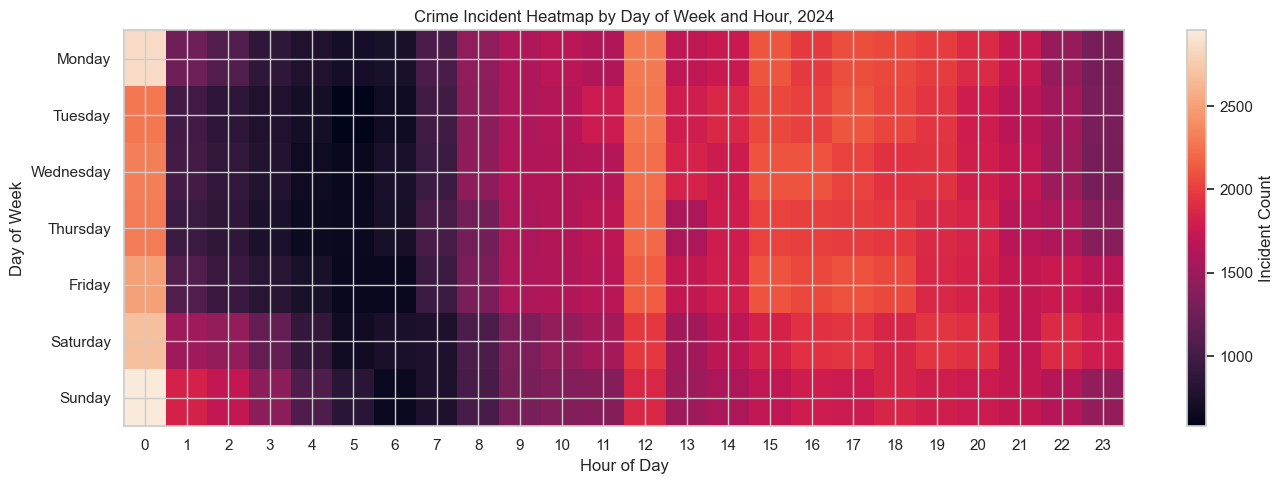

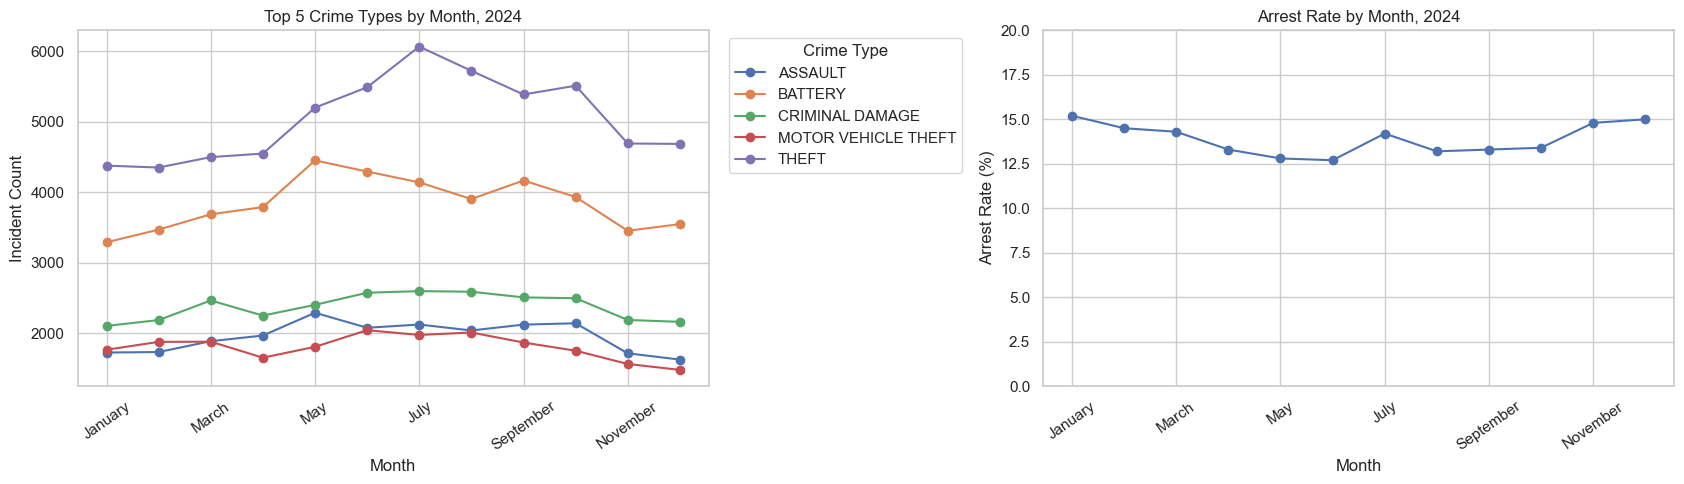

In [ ]:
import matplotlib.pyplot as plt


# Crimes by hour + crimes per weekday occurrence
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left chart: crimes by hour
axes[0].bar(hour_counts.index, hour_counts.values)
axes[0].set_title("Crime Incidents by Hour, 2024")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Incident Count")

# Right chart: crimes by weekday
axes[1].bar(weekday_counts_per_day.index, weekday_counts_per_day.values)
axes[1].set_title("Crime Incidents per Weekday Occurrence, 2024")
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Average Incidents per Calendar Day")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()



# Crimes per day by month

plt.figure(figsize=(12, 5))

plt.bar(month_counts_per_day.index, month_counts_per_day.values)

plt.title("Crime Incidents per Day by Month, 2024")
plt.xlabel("Month")
plt.ylabel("Average Incidents per Day")
plt.xticks(rotation=35)

plt.tight_layout()
plt.show()



# Heatmap: day_of_week x hour

plt.figure(figsize=(14, 5))

plt.imshow(heatmap_data, aspect="auto")

plt.title("Crime Incident Heatmap by Day of Week and Hour, 2024")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.colorbar(label="Incident Count")

plt.tight_layout()
plt.show()



# Top 5 crime types by month + arrest rate by month

fig, axes = plt.subplots(1, 2, figsize=(17, 5))

# Left chart: top 5 crime types by month
top5_monthly.plot(ax=axes[0], marker="o")

axes[0].set_title("Top 5 Crime Types by Month, 2024")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Incident Count")
axes[0].tick_params(axis="x", rotation=35)
axes[0].legend(title="Crime Type", bbox_to_anchor=(1.02, 1), loc="upper left")

# Right chart: arrest rate by month
monthly_arrest_rate.plot(ax=axes[1], marker="o")

axes[1].set_title("Arrest Rate by Month, 2024")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Arrest Rate (%)")
axes[1].tick_params(axis="x", rotation=35)
axes[1].set_ylim(0, max(monthly_arrest_rate.max() + 3, 20))

plt.tight_layout()
plt.show()

### B. Temporal Analysis Insights

The full-year data shows that crime incidents are not evenly distributed across the day. The highest raw incident count occurs at **12:00 AM**, with **17,903 incidents**, followed by **12:00 PM** with **14,978 incidents**. The lowest-volume period is the early morning, especially **5:00 AM** with **4,759 incidents** and **6:00 AM** with **4,931 incidents**. This suggests that midnight and midday reporting/incident patterns deserve extra attention in the final presentation.

After normalizing by the number of calendar days, the busiest months are **July** at about **777.4 incidents per day**, **June** at about **773.5 incidents per day**, and **September** at about **766.0 incidents per day**. The lowest normalized months are **December** at about **632.4 incidents per day** and **January** at about **634.0 incidents per day**. This supports a seasonal pattern where summer and early fall have higher daily incident volume.

Weekday differences are moderate after normalization. Raw counts make Monday look highest, but 2024 has 53 Mondays. After dividing by the number of each weekday in the year, **Saturday**, **Monday**, and **Friday** are very close, all around **718 incidents per calendar occurrence**. This is a useful example of why normalization matters.

The overall arrest rate is about **13.8%**. Monthly arrest rates are highest in **January** and **December**, around **15%**, and lower in late spring and summer, with **June** around **12.7%**. This does not prove why arrests vary, but it gives the group a clear time-based outcome pattern to discuss.


## C. Spatial Analysis + Map

This section studies where crime incidents are concentrated in Chicago. It includes district counts, district arrest rates, top and bottom community areas, an interactive Folium map, police station markers, sampled incident popups, district hotspot circle markers, a community-area choropleth when boundary data is reachable, and an approximate distance from each mapped crime incident to its nearest police station.

The Folium work intentionally follows the mapping patterns from the course module: base tile layers, layer controls, marker clusters, hover tooltips, click popups, and map layers that can be turned on or off.

The station-distance analysis should be interpreted carefully. It is a geographic proximity measure only; it does **not** measure patrol coverage, response time, staffing, or causation.

In [8]:
import folium
import numpy as np
from folium.plugins import HeatMap, MarkerCluster

POLICE_STATIONS_API_URL = "https://data.cityofchicago.org/resource/z8bn-74gv.json"
MAP_OUTPUT_FILE = "crime_heatmap_police_stations.html"

stations_response = requests.get(
    POLICE_STATIONS_API_URL,
    params={
        "$select": "district,district_name,address,latitude,longitude",
        "$limit": 50000,
    },
    timeout=60,
)
stations_response.raise_for_status()
stations = pd.DataFrame(stations_response.json())

stations["latitude"] = pd.to_numeric(stations["latitude"], errors="coerce")
stations["longitude"] = pd.to_numeric(stations["longitude"], errors="coerce")
stations = stations.dropna(subset=["latitude", "longitude"]).reset_index(drop=True)

for column in ["district", "district_name", "address"]:
    stations[column] = stations[column].astype("string").str.strip()

print("Police station records:", len(stations))
display(stations[["district", "district_name", "address", "latitude", "longitude"]])


Police station records: 23


,district,district_name,address,latitude,longitude
0,Headquarters,Headquarters,3510 S Michigan Ave,41.830702,-87.623395
1,18,Near North,1160 N Larrabee St,41.903242,-87.643352
2,19,Town Hall,850 W Addison St,41.947400,-87.651512
3,20,Lincoln,5400 N Lincoln Ave,41.979550,-87.692845
4,22,Morgan Park,1900 W Monterey Ave,41.691435,-87.668520
5,24,Rogers Park,6464 N Clark St,41.999763,-87.671324
6,25,Grand Central,5555 W Grand Ave,41.918609,-87.765574
7,1,Central,1718 S State St,41.858373,-87.627356
8,2,Wentworth,5101 S Wentworth Ave,41.801811,-87.630560
9,3,Grand Crossing,7040 S Cottage Grove Ave,41.766431,-87.605748


In [9]:
df_map = pd.read_csv(MAP_READY_FILE, parse_dates=["date"])
for column in ["arrest", "domestic", "is_weekend"]:
    df_map[column] = df_map[column].astype(str).str.lower().eq("true")

# District-level crime volume and arrest rates use the full cleaned dataset.
district_summary = (
    df.groupby("district")
    .agg(
        incident_count=("id", "count"),
        arrest_rate=("arrest", "mean"),
        mapped_incidents=("latitude", "count"),
    )
    .reset_index()
)
district_summary["arrest_rate_percent"] = (district_summary["arrest_rate"] * 100).round(1)
district_summary["district_label"] = district_summary["district"].astype("Int64").astype(str)

top_districts = district_summary.sort_values("incident_count", ascending=False).head(10)
low_arrest_large_districts = (
    district_summary[district_summary["incident_count"] >= 1000]
    .sort_values("arrest_rate_percent")
    .head(10)
)

community_counts = (
    df.dropna(subset=["community_area"])
    .groupby("community_area")
    .size()
    .rename("incident_count")
    .reset_index()
)
community_counts["community_area_label"] = community_counts["community_area"].astype("Int64").astype(str)
top_communities = community_counts.sort_values("incident_count", ascending=False).head(10)
bottom_communities = community_counts.sort_values("incident_count", ascending=True).head(10)

display(top_districts[["district_label", "incident_count", "arrest_rate_percent", "mapped_incidents"]])
display(low_arrest_large_districts[["district_label", "incident_count", "arrest_rate_percent"]])
display(top_communities[["community_area_label", "incident_count"]])
display(bottom_communities[["community_area_label", "incident_count"]])


,district_label,incident_count,arrest_rate_percent,mapped_incidents
7,8,17276,12.7,17164
11,12,16203,8.7,16099
0,1,14908,18.1,14833
5,6,14870,12.5,14778
17,19,14124,9.4,14036
3,4,13724,10.0,13640
10,11,13657,27.2,13579
16,18,13565,14.1,13485
21,25,13280,14.5,13197
1,2,13184,9.1,13114


,district_label,incident_count,arrest_rate_percent
11,12,16203,8.7
1,2,13184,9.1
17,19,14124,9.4
3,4,13724,10.0
15,17,7991,11.3
12,14,9896,11.4
14,16,9083,11.5
18,20,5676,11.9
20,24,8828,12.1
2,3,13145,12.3


,community_area_label,incident_count
24,25,12954
7,8,11432
27,28,10969
31,32,9326
42,43,8517
23,24,8005
22,23,7047
5,6,6828
70,71,6647
28,29,6606


,community_area_label,incident_count
8,9,283
46,47,296
11,12,544
73,74,549
17,18,673
36,37,705
54,55,804
35,36,882
71,72,915
58,59,1025


In [10]:
def add_nearest_station_distance(crime_df, stations_df, chunk_size=50000):
    """Add approximate nearest-station distance in miles using vectorized haversine distance."""
    result = crime_df.copy()

    crime_lat = np.radians(result["latitude"].to_numpy(dtype=float))
    crime_lon = np.radians(result["longitude"].to_numpy(dtype=float))
    station_lat = np.radians(stations_df["latitude"].to_numpy(dtype=float))
    station_lon = np.radians(stations_df["longitude"].to_numpy(dtype=float))

    min_distances = []
    nearest_station_index = []

    for start in range(0, len(result), chunk_size):
        end = min(start + chunk_size, len(result))
        lat1 = crime_lat[start:end, None]
        lon1 = crime_lon[start:end, None]
        dlat = station_lat[None, :] - lat1
        dlon = station_lon[None, :] - lon1
        a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(station_lat[None, :]) * np.sin(dlon / 2) ** 2
        distances = 3958.8 * 2 * np.arcsin(np.sqrt(a))
        nearest = distances.argmin(axis=1)
        nearest_station_index.extend(nearest)
        min_distances.extend(distances[np.arange(end - start), nearest])

    nearest_station_index = np.array(nearest_station_index)
    result["nearest_station_distance_miles"] = np.round(min_distances, 2)
    result["nearest_station_district"] = stations_df.loc[nearest_station_index, "district"].to_numpy()
    result["nearest_station_name"] = stations_df.loc[nearest_station_index, "district_name"].to_numpy()

    return result


df_map = add_nearest_station_distance(df_map, stations)

distance_summary = (
    df_map.groupby("district")
    .agg(
        mapped_incidents=("id", "count"),
        median_nearest_station_miles=("nearest_station_distance_miles", "median"),
        average_nearest_station_miles=("nearest_station_distance_miles", "mean"),
    )
    .reset_index()
)
distance_summary["district_label"] = distance_summary["district"].astype("Int64").astype(str)
distance_summary["median_nearest_station_miles"] = distance_summary["median_nearest_station_miles"].round(2)
distance_summary["average_nearest_station_miles"] = distance_summary["average_nearest_station_miles"].round(2)

display(df_map["nearest_station_distance_miles"].describe(percentiles=[0.25, 0.5, 0.75, 0.9]).round(2))
display(distance_summary.sort_values("median_nearest_station_miles", ascending=False).head(10))


count    257531.00
mean          1.24
std           0.75
min           0.01
25%           0.76
50%           1.15
75%           1.56
90%           2.08
max           8.78
Name: nearest_station_distance_miles, dtype: float64

,district,mapped_incidents,median_nearest_station_miles,average_nearest_station_miles,district_label
22,31,13,6.70,6.35,31
3,4,13640,2.01,1.98,4
14,16,9014,1.84,2.50,16
19,22,7925,1.60,1.50,22
7,8,17164,1.57,1.73,8
4,5,10191,1.41,1.47,5
8,9,11293,1.37,1.37,9
0,1,14833,1.26,1.12,1
21,25,13197,1.25,1.25,25
10,11,13579,1.23,1.15,11


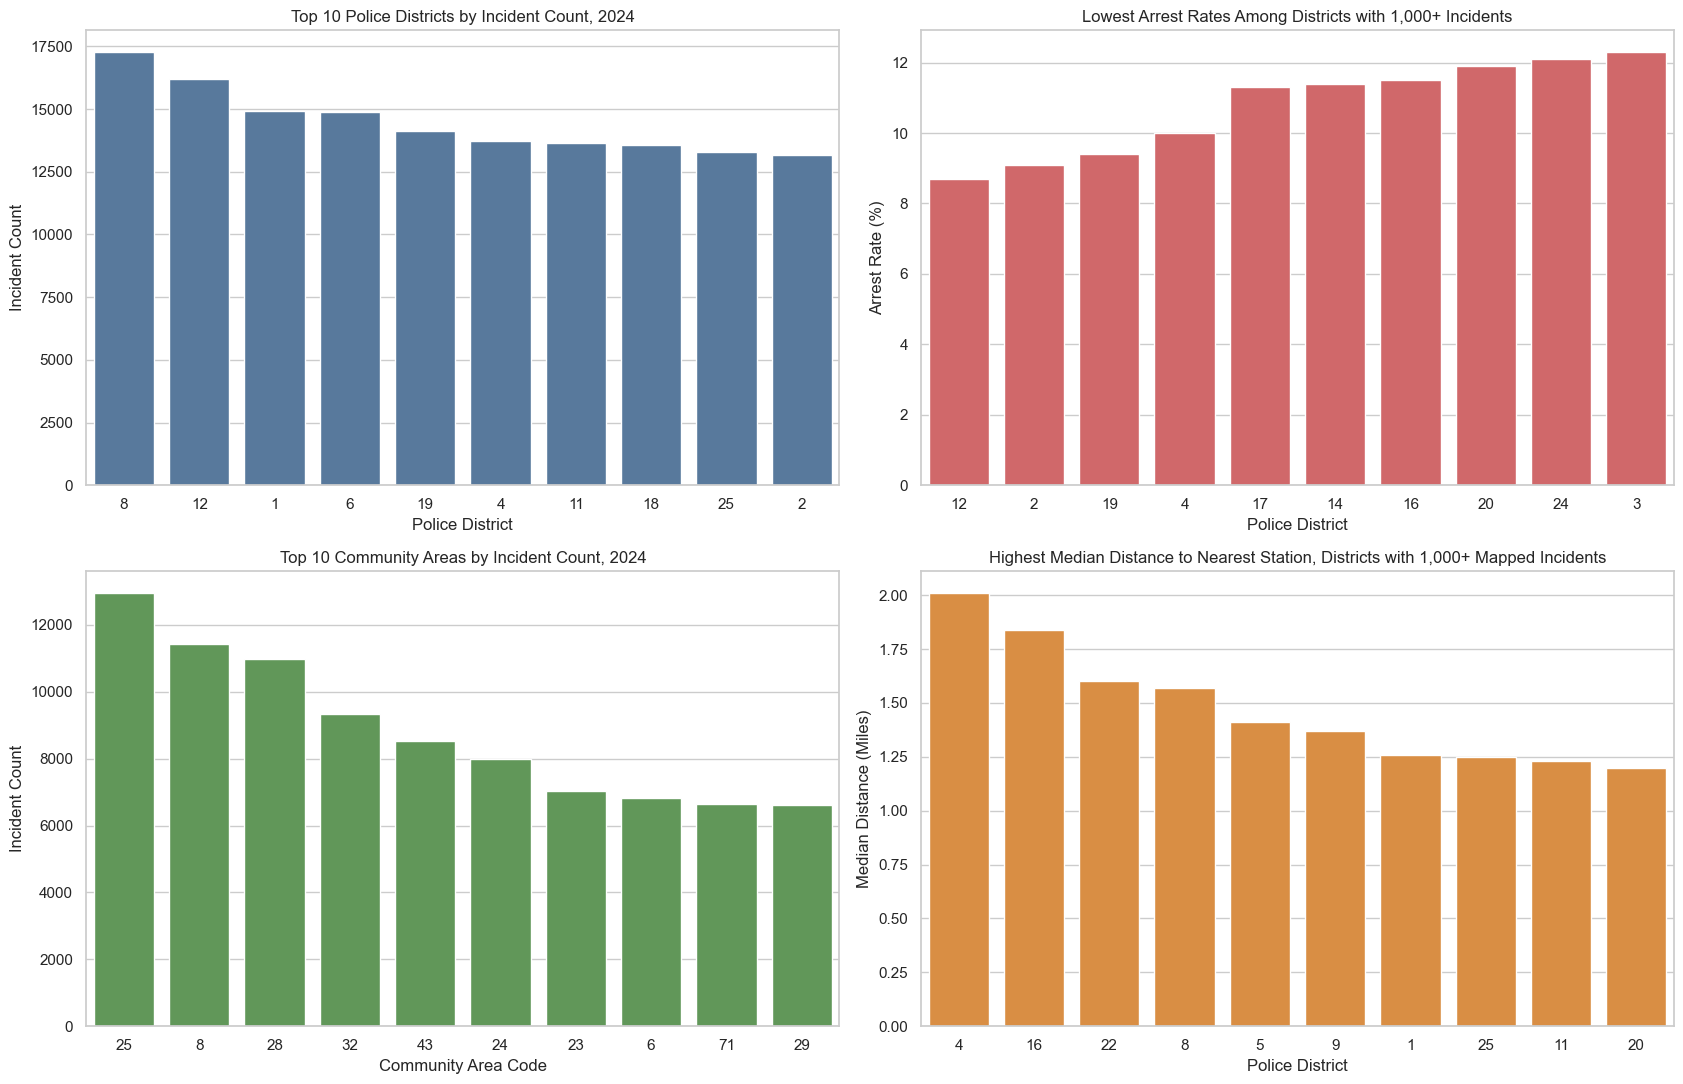

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(17, 11))

sns.barplot(data=top_districts, x="district_label", y="incident_count", color="#4c78a8", ax=axes[0, 0])
axes[0, 0].set_title("Top 10 Police Districts by Incident Count, 2024")
axes[0, 0].set_xlabel("Police District")
axes[0, 0].set_ylabel("Incident Count")

sns.barplot(data=low_arrest_large_districts, x="district_label", y="arrest_rate_percent", color="#e15759", ax=axes[0, 1])
axes[0, 1].set_title("Lowest Arrest Rates Among Districts with 1,000+ Incidents")
axes[0, 1].set_xlabel("Police District")
axes[0, 1].set_ylabel("Arrest Rate (%)")

sns.barplot(data=top_communities, x="community_area_label", y="incident_count", color="#59a14f", ax=axes[1, 0])
axes[1, 0].set_title("Top 10 Community Areas by Incident Count, 2024")
axes[1, 0].set_xlabel("Community Area Code")
axes[1, 0].set_ylabel("Incident Count")

normal_distance_summary = distance_summary[distance_summary["mapped_incidents"] >= 1000].sort_values(
    "median_nearest_station_miles", ascending=False
).head(10)
sns.barplot(data=normal_distance_summary, x="district_label", y="median_nearest_station_miles", color="#f28e2b", ax=axes[1, 1])
axes[1, 1].set_title("Highest Median Distance to Nearest Station, Districts with 1,000+ Mapped Incidents")
axes[1, 1].set_xlabel("Police District")
axes[1, 1].set_ylabel("Median Distance (Miles)")

plt.tight_layout()
plt.show()


In [12]:
from html import escape
from IPython.display import IFrame, display

COMMUNITY_BOUNDARIES_URL = "https://data.cityofchicago.org/api/geospatial/igwz-8jzy?method=export&format=GeoJSON"
MAP_SAMPLE_SIZE = 15000
INCIDENT_MARKER_SAMPLE_SIZE = 750

map_sample = df_map.sample(n=min(MAP_SAMPLE_SIZE, len(df_map)), random_state=5840)
incident_marker_sample = df_map.sample(n=min(INCIDENT_MARKER_SAMPLE_SIZE, len(df_map)), random_state=5841)

crime_station_map = folium.Map(location=[41.8781, -87.6298], zoom_start=11, tiles=None)

folium.TileLayer("CartoDB positron", name="CartoDB Positron", control=True).add_to(crime_station_map)
folium.TileLayer("OpenStreetMap", name="OpenStreetMap", control=True).add_to(crime_station_map)
folium.TileLayer(
    tiles="https://{s}.tile.opentopomap.org/{z}/{x}/{y}.png",
    attr="Map data: OpenStreetMap contributors, SRTM | Map style: OpenTopoMap (CC-BY-SA)",
    name="OpenTopoMap",
    control=True,
).add_to(crime_station_map)

community_map_summary = (
    df_map.dropna(subset=["community_area"])
    .groupby("community_area")
    .agg(
        incident_count=("id", "count"),
        arrest_rate=("arrest", "mean"),
        latitude=("latitude", "mean"),
        longitude=("longitude", "mean"),
    )
    .reset_index()
)
community_map_summary["community_area_label"] = community_map_summary["community_area"].astype("Int64").astype(str)
community_map_summary["arrest_rate_percent"] = (community_map_summary["arrest_rate"] * 100).round(1)

try:
    boundary_response = requests.get(COMMUNITY_BOUNDARIES_URL, timeout=60)
    boundary_response.raise_for_status()
    community_geojson = boundary_response.json()

    community_lookup = community_map_summary.set_index("community_area_label").to_dict("index")
    for feature in community_geojson.get("features", []):
        properties = feature.setdefault("properties", {})
        area_label = str(properties.get("area_numbe") or properties.get("area_num_1") or "").strip()
        stats = community_lookup.get(area_label, {})
        properties["incident_count"] = int(stats.get("incident_count", 0) or 0)
        properties["arrest_rate_percent"] = round(float(stats.get("arrest_rate_percent", 0) or 0), 1)

    folium.Choropleth(
        geo_data=community_geojson,
        data=community_map_summary,
        columns=["community_area_label", "incident_count"],
        key_on="feature.properties.area_numbe",
        name="Community area incident choropleth",
        fill_color="YlOrRd",
        fill_opacity=0.55,
        line_opacity=0.35,
        legend_name="2024 crime incidents by community area",
    ).add_to(crime_station_map)

    folium.GeoJson(
        community_geojson,
        name="Community area hover details",
        style_function=lambda feature: {
            "fillOpacity": 0,
            "color": "#555555",
            "weight": 0.6,
        },
        tooltip=folium.GeoJsonTooltip(
            fields=["community", "area_numbe", "incident_count", "arrest_rate_percent"],
            aliases=["Community", "Area code", "2024 incidents", "Arrest rate (%)"],
            localize=True,
            sticky=False,
        ),
    ).add_to(crime_station_map)
    print("Loaded community-area boundary layer:", len(community_geojson.get("features", [])), "features")
except Exception as exc:
    community_geojson = None
    print("Community boundary layer skipped:", exc)

heatmap_layer = folium.FeatureGroup(name=f"Crime heatmap sample ({len(map_sample):,} incidents)", show=True)
HeatMap(
    map_sample[["latitude", "longitude"]].dropna().values.tolist(),
    radius=8,
    blur=12,
    min_opacity=0.25,
).add_to(heatmap_layer)
heatmap_layer.add_to(crime_station_map)

def arrest_rate_color(rate):
    if rate < 10:
        return "red"
    if rate < 14:
        return "orange"
    return "green"

# Circle markers summarize district hotspots without needing district boundary polygons.
district_centers = (
    df_map.groupby("district")
    .agg(latitude=("latitude", "mean"), longitude=("longitude", "mean"))
    .reset_index()
)
district_map_summary = district_summary.merge(district_centers, on="district", how="left").dropna(
    subset=["latitude", "longitude"]
)
district_layer = folium.FeatureGroup(name="District hotspot circle markers", show=True)
max_district_count = district_map_summary["incident_count"].max()
for _, row in district_map_summary.sort_values("incident_count", ascending=False).iterrows():
    radius = 5 + 18 * (row["incident_count"] / max_district_count)
    popup_html = f"""
    <b>Police District {escape(str(row['district_label']))}</b><br>
    2024 incidents: {int(row['incident_count']):,}<br>
    Arrest rate: {row['arrest_rate_percent']:.1f}%<br>
    Mapped incidents: {int(row['mapped_incidents']):,}
    """
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=radius,
        color=arrest_rate_color(row["arrest_rate_percent"]),
        fill=True,
        fill_color=arrest_rate_color(row["arrest_rate_percent"]),
        fill_opacity=0.55,
        weight=2,
        popup=folium.Popup(popup_html, max_width=300),
        tooltip=f"District {row['district_label']}: {int(row['incident_count']):,} incidents",
    ).add_to(district_layer)
district_layer.add_to(crime_station_map)

incident_cluster = MarkerCluster(name=f"Sample incident popups ({len(incident_marker_sample):,} incidents)", show=False).add_to(
    crime_station_map
)
for _, incident in incident_marker_sample.iterrows():
    arrest_label = "Arrest" if bool(incident["arrest"]) else "No arrest recorded"
    popup_html = f"""
    <b>{escape(str(incident['primary_type']))}</b><br>
    Date: {incident['date'].strftime('%Y-%m-%d %H:%M')}<br>
    District: {int(incident['district'])}<br>
    Location: {escape(str(incident['location_description']))}<br>
    Outcome: {arrest_label}<br>
    Case: {escape(str(incident['case_number']))}
    """
    folium.Marker(
        location=[incident["latitude"], incident["longitude"]],
        popup=folium.Popup(popup_html, max_width=320),
        tooltip=f"{incident['primary_type']} - District {int(incident['district'])}",
        icon=folium.Icon(color="green" if bool(incident["arrest"]) else "gray", icon="info-sign"),
    ).add_to(incident_cluster)

station_cluster = MarkerCluster(name="Police station markers", show=True).add_to(crime_station_map)
for _, station in stations.iterrows():
    popup = f"<b>{escape(str(station['district_name']))}</b><br>{escape(str(station['address']))}<br>District: {escape(str(station['district']))}"
    folium.Marker(
        location=[station["latitude"], station["longitude"]],
        popup=folium.Popup(popup, max_width=320),
        tooltip=f"Police station: {station['district_name']}",
        icon=folium.Icon(color="blue", icon="info-sign"),
    ).add_to(station_cluster)

folium.LayerControl(collapsed=False).add_to(crime_station_map)
crime_station_map.save(MAP_OUTPUT_FILE)
print("Saved enhanced interactive map:", MAP_OUTPUT_FILE)
print(
    "Map layers: tile controls, community-area choropleth, heatmap sample, district hotspot circles, "
    "sample incident popups, and police station markers."
)
display(IFrame(MAP_OUTPUT_FILE, width="100%", height=650))

Loaded community-area boundary layer: 77 features
Saved enhanced interactive map: crime_heatmap_police_stations.html
Map layers: tile controls, community-area choropleth, heatmap sample, district hotspot circles, sample incident popups, and police station markers.


### C. Spatial Analysis Insights

District-level incident volume is concentrated in a small set of districts. **District 8** has the highest count with **17,276 incidents**, followed by **District 12** with **16,203**, **District 1** with **14,908**, and **District 6** with **14,870**. These districts should be treated as major spatial hotspots in the presentation.

Arrest rates vary substantially by district. Among districts with at least 1,000 incidents, **District 12** has the lowest arrest rate at about **8.7%**, followed by **District 2** at **9.1%**, **District 19** at **9.4%**, and **District 4** at **10.0%**. These are useful candidates for the final decision-support discussion because they combine meaningful volume with relatively low arrest outcomes.

Community-area counts also show concentration. The highest-count community areas are **25** with **12,954 incidents**, **8** with **11,432**, and **28** with **10,969**. The bottom community areas have far fewer incidents, including **9** with **283** and **47** with **296**.

The enhanced Folium map now uses the same kinds of techniques practiced in the class mapping module: multiple tile layers, LayerControl, marker clusters, hover tooltips, click popups, a sampled crime heatmap, police station markers, district hotspot circle markers, and a community-area choropleth when the Chicago boundary export is available. The incident popups are sampled for browser performance, while the district, community-area, and distance summaries use the full mapped dataset.

The median mapped incident is about **1.15 miles** from the nearest listed police station, and the 90th percentile is about **2.08 miles**. This distance measure is only a rough geographic context variable and should not be described as actual police coverage or response time.

## D. Crime Type + Arrest Outcome + COPA Supplement

This section studies what kinds of crimes are most common, how arrest outcomes differ by offense type, how domestic incidents compare with non-domestic incidents, and which location categories appear most frequently. It also adds a limited COPA supplement using high-level complaint status and complaint category charts.

The COPA section is intentionally limited. Most 2024 COPA records do not have a known beat, so we should not make strong district-level accountability claims from that dataset.


In [13]:
import plotly.express as px

crime_type_summary = (
    df.groupby("primary_type")
    .agg(
        incident_count=("id", "count"),
        arrest_rate=("arrest", "mean"),
    )
    .reset_index()
    .sort_values("incident_count", ascending=False)
)
crime_type_summary["arrest_rate_percent"] = (crime_type_summary["arrest_rate"] * 100).round(1)
top15_crime_types = crime_type_summary.head(15)

domestic_summary = (
    df.groupby("domestic")
    .agg(
        incident_count=("id", "count"),
        arrest_rate=("arrest", "mean"),
    )
    .reset_index()
)
domestic_summary["domestic_label"] = domestic_summary["domestic"].map({False: "Non-domestic", True: "Domestic"})
domestic_summary["arrest_rate_percent"] = (domestic_summary["arrest_rate"] * 100).round(1)

location_summary = (
    df["location_description"]
    .fillna("UNKNOWN / NOT LISTED")
    .value_counts()
    .head(12)
    .rename_axis("location_description")
    .reset_index(name="incident_count")
)

display(top15_crime_types)
display(domestic_summary[["domestic_label", "incident_count", "arrest_rate_percent"]])
display(location_summary)


,primary_type,incident_count,arrest_rate,arrest_rate_percent
29,THEFT,60542,0.068168,6.8
2,BATTERY,46147,0.171235,17.1
5,CRIMINAL DAMAGE,28554,0.038769,3.9
1,ASSAULT,23482,0.107827,10.8
16,MOTOR VEHICLE THEFT,21711,0.028050,2.8
22,OTHER OFFENSE,17130,0.192411,19.2
8,DECEPTIVE PRACTICE,16315,0.033037,3.3
26,ROBBERY,9110,0.082986,8.3
3,BURGLARY,8431,0.055391,5.5
30,WEAPONS VIOLATION,7839,0.613344,61.3


,domestic_label,incident_count,arrest_rate_percent
0,Non-domestic,211505,13.6
1,Domestic,47606,14.9


,location_description,incident_count
0,STREET,69621
1,APARTMENT,49503
2,RESIDENCE,31089
3,SIDEWALK,13816
4,SMALL RETAIL STORE,9773
5,PARKING LOT / GARAGE (NON RESIDENTIAL),8833
6,RESTAURANT,6250
7,ALLEY,5925
8,DEPARTMENT STORE,5681
9,OTHER (SPECIFY),4162


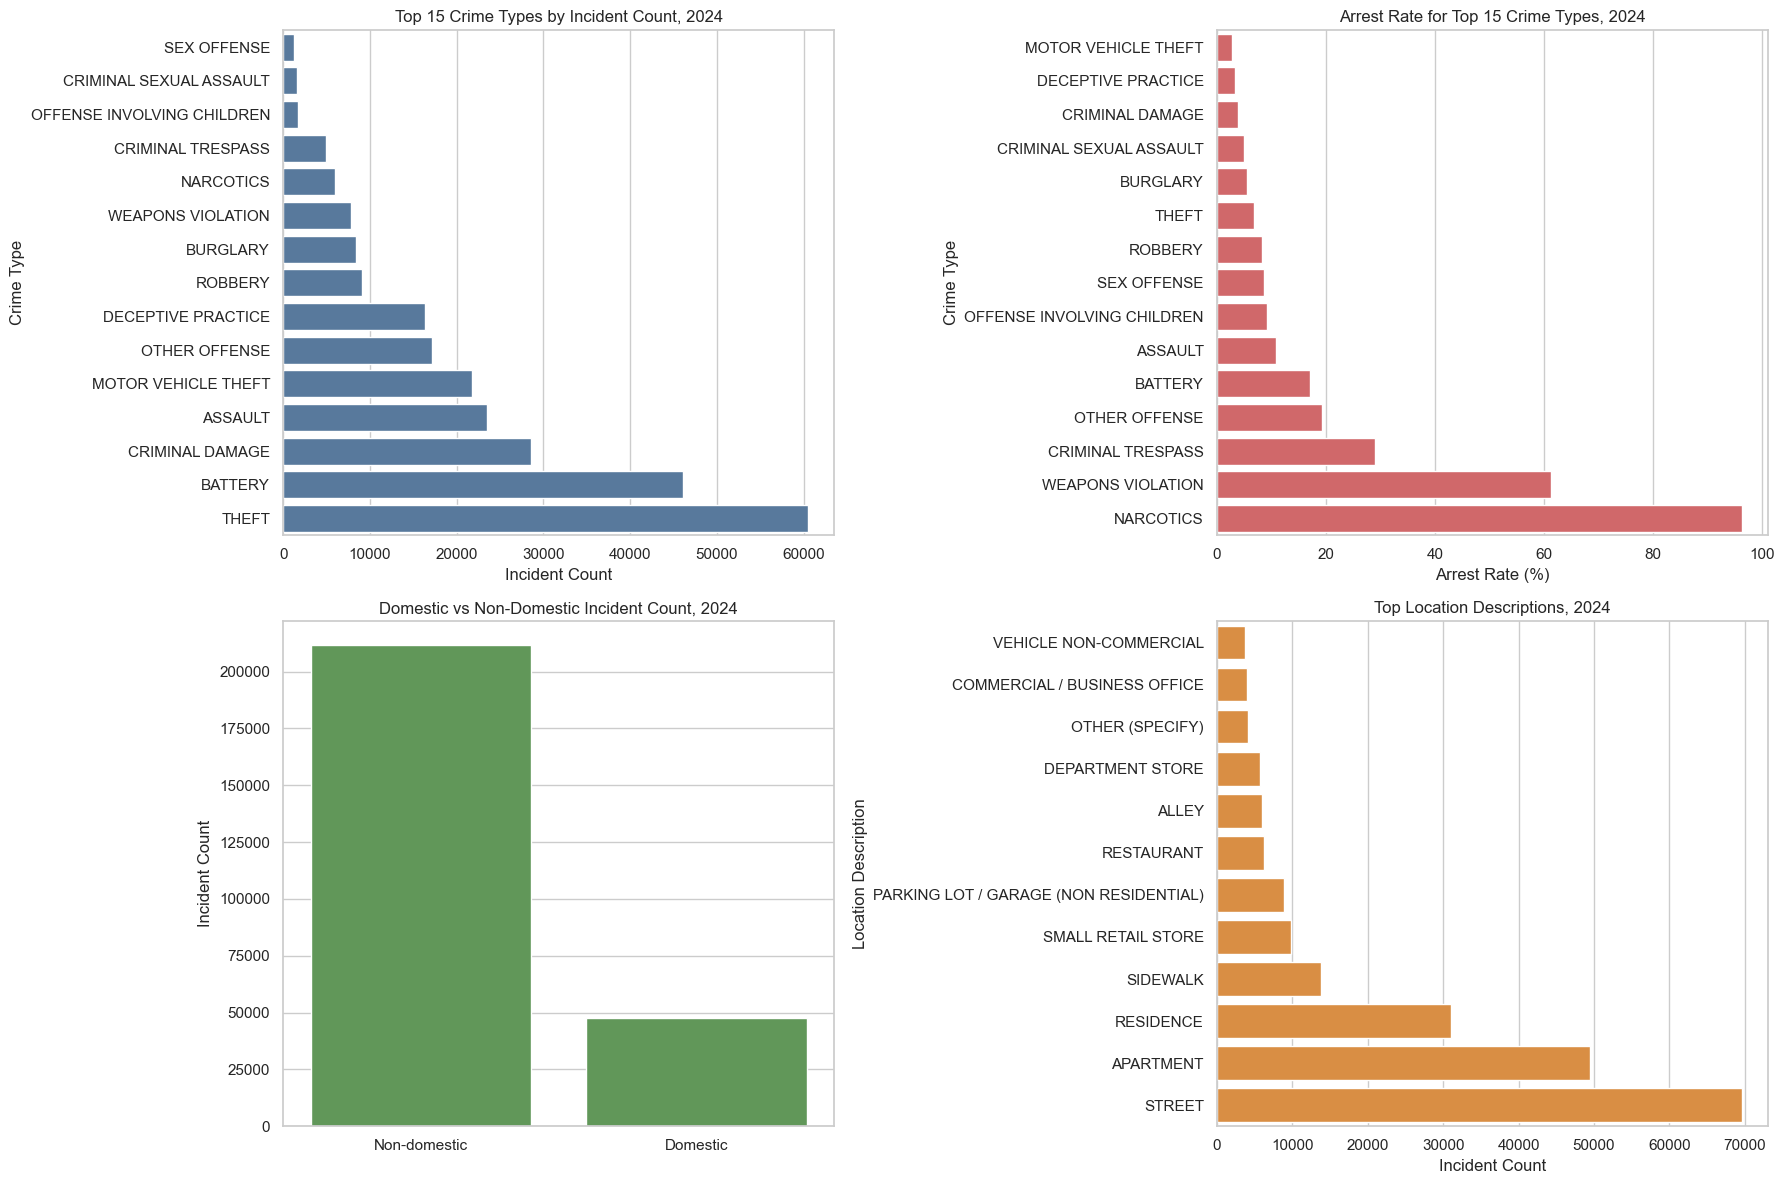

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

top15_for_bar = top15_crime_types.sort_values("incident_count", ascending=True)
sns.barplot(data=top15_for_bar, x="incident_count", y="primary_type", color="#4c78a8", ax=axes[0, 0])
axes[0, 0].set_title("Top 15 Crime Types by Incident Count, 2024")
axes[0, 0].set_xlabel("Incident Count")
axes[0, 0].set_ylabel("Crime Type")

arrest_top15 = top15_crime_types.sort_values("arrest_rate_percent", ascending=True)
sns.barplot(data=arrest_top15, x="arrest_rate_percent", y="primary_type", color="#e15759", ax=axes[0, 1])
axes[0, 1].set_title("Arrest Rate for Top 15 Crime Types, 2024")
axes[0, 1].set_xlabel("Arrest Rate (%)")
axes[0, 1].set_ylabel("Crime Type")

sns.barplot(data=domestic_summary, x="domestic_label", y="incident_count", color="#59a14f", ax=axes[1, 0])
axes[1, 0].set_title("Domestic vs Non-Domestic Incident Count, 2024")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Incident Count")

location_for_bar = location_summary.sort_values("incident_count", ascending=True)
sns.barplot(data=location_for_bar, x="incident_count", y="location_description", color="#f28e2b", ax=axes[1, 1])
axes[1, 1].set_title("Top Location Descriptions, 2024")
axes[1, 1].set_xlabel("Incident Count")
axes[1, 1].set_ylabel("Location Description")

plt.tight_layout()
plt.show()

interactive_crime_chart = px.bar(
    top15_crime_types.sort_values("incident_count", ascending=False),
    x="primary_type",
    y="incident_count",
    color="arrest_rate_percent",
    color_continuous_scale="Reds",
    title="Interactive View: Top 15 Crime Types and Arrest Rates, 2024",
    labels={
        "primary_type": "Crime Type",
        "incident_count": "Incident Count",
        "arrest_rate_percent": "Arrest Rate (%)",
    },
)
interactive_crime_chart.update_layout(xaxis_tickangle=-35, height=550)
interactive_crime_chart


,metric,value
0,copa_2024_records,6375
1,records_with_known_beat,865
2,records_with_unknown_or_missing_beat,5510


,current_status,case_count
0,UNKNOWN / NOT LISTED,5269
1,Closed,918
2,Pending CPD Review,118
3,Pending Investigation,70


,current_category,case_count
0,UNKNOWN / NOT LISTED,5269
1,Closed-No Allegation,214
2,Crime Misconduct,147
3,Excessive Force,90
4,Domestic Incidents,73
5,Operation/Personnel Violations,33
6,Excessive Force | Excessive Force,30
7,Sexual Misconduct,24
8,Civil Rights Violation,20
9,Civil Rights Violation | Civil Rights Violation,17


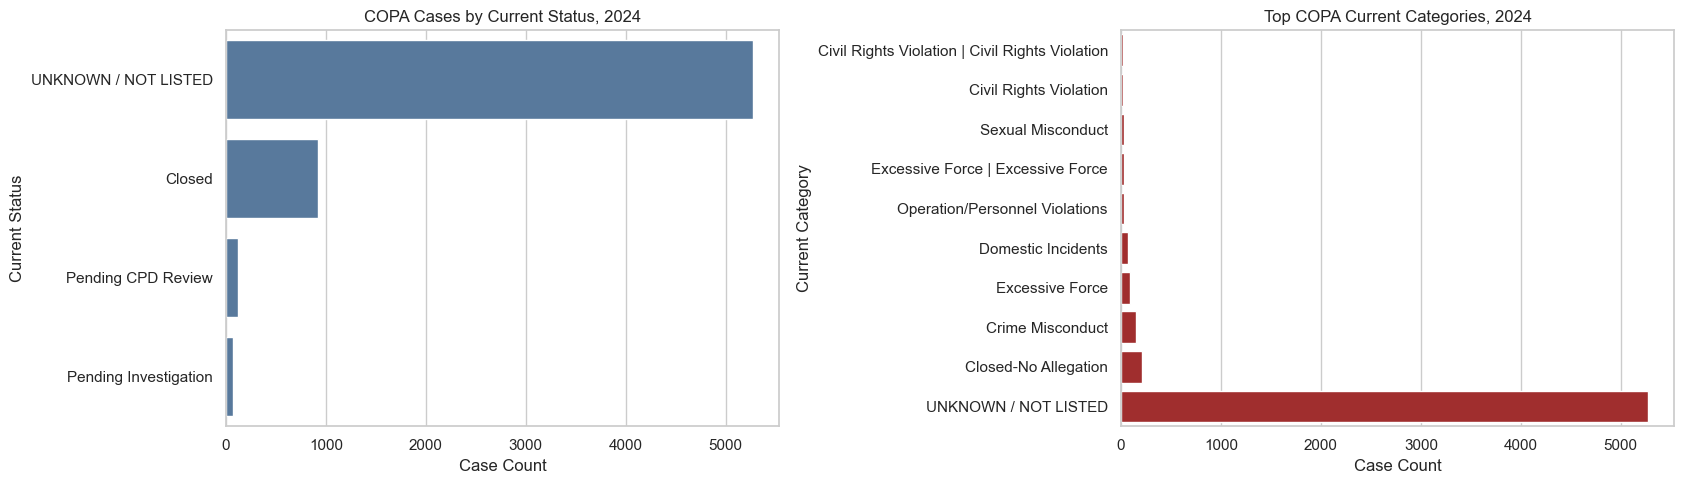

In [15]:
COPA_API_URL = "https://data.cityofchicago.org/resource/mft5-nfa8.json"
COPA_COLUMNS = [
    "complaint_date",
    "assignment",
    "case_type",
    "current_status",
    "current_category",
    "police_shooting",
    "beat",
    "complaint_hour",
    "complaint_day",
    "complaint_month",
]
COPA_WHERE = "complaint_date >= '2024-01-01T00:00:00' AND complaint_date < '2025-01-01T00:00:00'"

copa_response = requests.get(
    COPA_API_URL,
    params={
        "$select": ",".join(COPA_COLUMNS),
        "$where": COPA_WHERE,
        "$order": "complaint_date ASC",
        "$limit": 50000,
    },
    timeout=60,
)
copa_response.raise_for_status()
copa = pd.DataFrame(copa_response.json())

for column in COPA_COLUMNS:
    if column not in copa.columns:
        copa[column] = pd.NA

copa["complaint_date"] = pd.to_datetime(copa["complaint_date"], errors="coerce")
for column in ["current_status", "current_category", "beat", "assignment", "case_type", "police_shooting"]:
    copa[column] = copa[column].fillna("UNKNOWN / NOT LISTED").replace("", "UNKNOWN / NOT LISTED")

copa["beat_known"] = ~copa["beat"].isin(["Unknown", "UNKNOWN / NOT LISTED"])

copa_status_counts = copa["current_status"].value_counts().rename_axis("current_status").reset_index(name="case_count")
copa_category_counts = copa["current_category"].value_counts().head(10).rename_axis("current_category").reset_index(name="case_count")

copa_summary = pd.DataFrame({
    "metric": ["copa_2024_records", "records_with_known_beat", "records_with_unknown_or_missing_beat"],
    "value": [len(copa), int(copa["beat_known"].sum()), int((~copa["beat_known"]).sum())],
})

display(copa_summary)
display(copa_status_counts)
display(copa_category_counts)

fig, axes = plt.subplots(1, 2, figsize=(17, 5))
sns.barplot(data=copa_status_counts, x="case_count", y="current_status", color="#4c78a8", ax=axes[0])
axes[0].set_title("COPA Cases by Current Status, 2024")
axes[0].set_xlabel("Case Count")
axes[0].set_ylabel("Current Status")

category_for_bar = copa_category_counts.sort_values("case_count", ascending=True)
sns.barplot(data=category_for_bar, x="case_count", y="current_category", color="#b31b1b", ax=axes[1])
axes[1].set_title("Top COPA Current Categories, 2024")
axes[1].set_xlabel("Case Count")
axes[1].set_ylabel("Current Category")

plt.tight_layout()
plt.show()


### D. Crime Type, Arrest Outcome, and COPA Insights

The most common crime type in 2024 is **THEFT** with **60,542 incidents**, followed by **BATTERY** with **46,147**, **CRIMINAL DAMAGE** with **28,554**, **ASSAULT** with **23,482**, and **MOTOR VEHICLE THEFT** with **21,711**. This means the final presentation should not treat all crime categories as equally important; a small number of categories account for a large share of incidents.

Arrest rates vary sharply by crime type. Among the most common categories, **MOTOR VEHICLE THEFT** has an arrest rate of about **2.8%**, **DECEPTIVE PRACTICE** about **3.3%**, and **CRIMINAL DAMAGE** about **3.9%**. In contrast, **NARCOTICS** has an arrest rate around **96.3%** and **WEAPONS VIOLATION** around **61.3%**. This likely reflects differences in how these incidents are reported, observed, and enforced, so we should describe it as an outcome pattern rather than a causal explanation.

Domestic incidents make up **47,606** records, compared with **211,505** non-domestic records. The arrest rate is slightly higher for domestic incidents, about **14.9%**, compared with **13.6%** for non-domestic incidents. The most common location descriptions are **STREET** with **69,621 incidents**, **APARTMENT** with **49,503**, and **RESIDENCE** with **31,089**.

The COPA supplement includes **6,375** 2024 records, but **5,510** have unknown or missing beat information. Because of that, COPA should be used only for high-level complaint status and category context. We should not make strong district-level accountability claims from COPA in the final report.


## E. Final Synthesis + Decision-Support Priority

This final section connects the four analysis tracks into one decision-support view. The priority score is not a causal model and should not be interpreted as a measure of police performance. It is a transparent ranking that helps the team identify districts where several observed patterns overlap: high incident volume, lower arrest outcome rates, and longer median distance to a listed police station.

The weights are intentionally simple for presentation: 45% incident volume, 35% low arrest-rate score, and 20% nearest-station distance. Districts with fewer than 1,000 incidents are excluded so small areas do not rank highly from unstable rates or distance values.

,district,incidents,arrest_rate_pct,median_station_distance_miles,priority_score
7,8,17276,12.7,1.57,84.8
3,4,13724,10.0,2.01,83.8
11,12,16203,8.7,1.18,81.4
17,19,14124,9.4,1.02,69.2
5,6,14870,12.5,1.10,67.7
1,2,13184,9.1,1.02,66.2
2,3,13145,12.3,1.11,61.5
21,25,13280,14.5,1.25,60.3
0,1,14908,18.1,1.26,60.0
14,16,9083,11.5,1.84,60.0


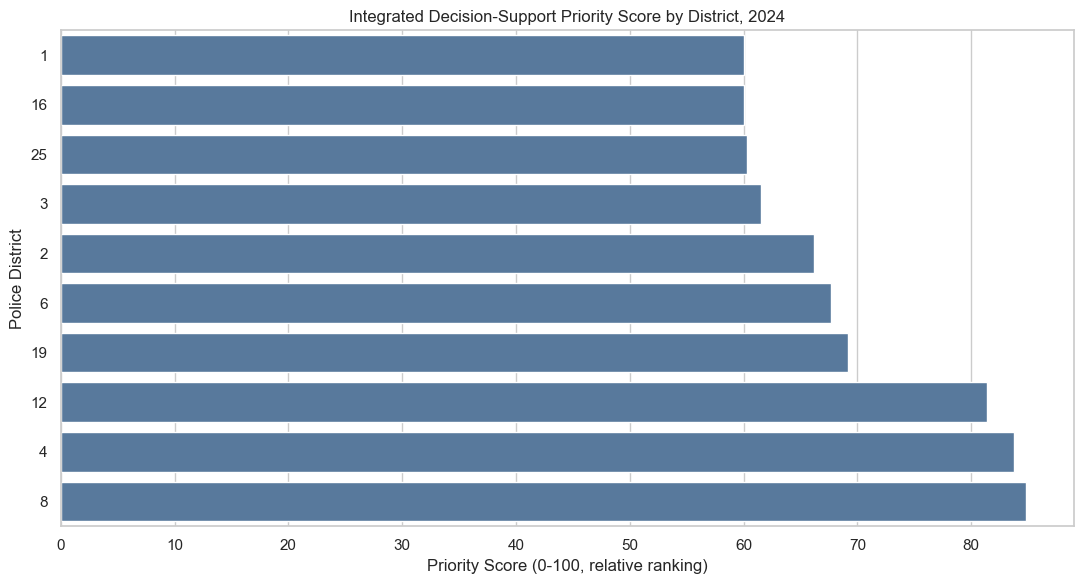

Interpretation: prioritize districts near the top of this table for deeper discussion, not as proof of causation or direct policy effectiveness.


In [16]:
priority_table = district_summary.merge(
    distance_summary[["district", "median_nearest_station_miles"]],
    on="district",
    how="left",
)
priority_table = priority_table[priority_table["incident_count"] >= 1000].copy()


def minmax_score(series):
    if series.max() == series.min():
        return pd.Series(0.0, index=series.index)
    return (series - series.min()) / (series.max() - series.min())


priority_table["volume_score"] = minmax_score(priority_table["incident_count"])
priority_table["low_arrest_score"] = 1 - minmax_score(priority_table["arrest_rate_percent"])
priority_table["distance_score"] = minmax_score(
    priority_table["median_nearest_station_miles"].fillna(priority_table["median_nearest_station_miles"].median())
)
priority_table["priority_score"] = (
    0.45 * priority_table["volume_score"]
    + 0.35 * priority_table["low_arrest_score"]
    + 0.20 * priority_table["distance_score"]
) * 100

decision_priority = (
    priority_table
    .sort_values("priority_score", ascending=False)
    [[
        "district_label",
        "incident_count",
        "arrest_rate_percent",
        "median_nearest_station_miles",
        "priority_score",
    ]]
    .rename(columns={
        "district_label": "district",
        "incident_count": "incidents",
        "arrest_rate_percent": "arrest_rate_pct",
        "median_nearest_station_miles": "median_station_distance_miles",
    })
)
decision_priority["priority_score"] = decision_priority["priority_score"].round(1)

display(decision_priority.head(10))

plt.figure(figsize=(11, 6))
sns.barplot(
    data=decision_priority.head(10).sort_values("priority_score"),
    x="priority_score",
    y="district",
    color="#4c78a8",
)
plt.title("Integrated Decision-Support Priority Score by District, 2024")
plt.xlabel("Priority Score (0-100, relative ranking)")
plt.ylabel("Police District")
plt.tight_layout()
plt.show()

print(
    "Interpretation: prioritize districts near the top of this table for deeper discussion, "
    "not as proof of causation or direct policy effectiveness."
)

### Final Takeaways and Limitations

The strongest project story is that 2024 Chicago crime incidents show clear temporal, spatial, and offense-type concentration. Incidents are higher in the summer and early fall, several police districts and community areas account for a large share of total volume, and a small number of crime types such as theft, battery, criminal damage, assault, and motor vehicle theft dominate the dataset. Arrest outcomes vary much more by crime type and district than the overall arrest rate alone suggests.

For the final report and presentation, the team should frame the decision-support table as a way to choose where to ask better questions next. Districts near the top deserve closer review because high volume, lower arrest outcome rates, and distance context overlap there. That does not prove a cause, and it does not measure safety, staffing, response time, prosecution, or community trust.

Important limitations should be stated clearly: latitude and longitude are missing for 1,580 crime records; station distance is only approximate straight-line distance to listed police stations; arrest is an administrative outcome rather than a complete measure of case resolution; COPA is useful only as high-level accountability context because most 2024 records have unknown or missing beat information; and City of Chicago portal records can be updated after download. The final written conclusion should be rewritten by the team in its own words and should cite any AI-assisted code or drafting help required by the course policy.